# Captain Cook HTR — Three-Experiment CER/WER Comparison

## Objective
Compare three TrOCR models on the Captain Cook (Forster) manuscript:

| Experiment | Model | Training |
|---|---|---|
| A | `trocr-base-handwritten` | Zero-shot — no fine-tuning |
| B | `best_trocr_model` | Fine-tuned on Bentham only |
| C | `CC_fine-tuned_TrOCR` | Bentham + Cook fine-tuning |

### Dataset
- 30 pages from Forster's journal (Bd1–Bd6), contributed by 3 team members
- Train: 24 pages, Val: 6 pages (last page per volume, for early stopping)
- Test: 6 separate pages (one per volume, from test_set_line_crops folder)
- B3/B4 and B1/B2 images are JPG — B5/B6 images are PNG (and JPG in test)

### Workflow
1. Imports
2. Seed and device
3. Paths, train/val split, and test set
4. Build paired line lists
5. Dataset classes
6. Collator, metrics, predict, evaluate
7. Experiment A — zero-shot trocr-base
8. Experiment B — Bentham fine-tuned
9. Experiment C — fine-tune on Cook train, validate on val, test on test
10. Compare all three
11. Plot results
12. Save CSV

## Cell 1 — Imports

In [1]:
import os
import random
import copy
from pathlib import Path

import pandas as pd
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchvision import transforms

from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    get_linear_schedule_with_warmup
)

import editdistance
from jiwer import wer as compute_wer_jiwer
from tqdm import tqdm

print("All imports successful.")

All imports successful.


In [2]:
from pathlib import Path

TEST_DIR = Path("data/Captain_Cook/test_set_line_crops")

print(f"Exists: {TEST_DIR.exists()}")
print()
for subfolder in sorted(TEST_DIR.iterdir()):
    if not subfolder.is_dir():
        continue
    imgs = list(subfolder.glob("*.jpg")) + list(subfolder.glob("*.png"))
    txts = list(subfolder.glob("*.txt"))
    imgs = [f for f in imgs if not f.name.startswith(".")]
    sample = sorted(subfolder.iterdir())[0].name if list(subfolder.iterdir()) else "empty"
    print(f"  {subfolder.name:<25} {len(imgs):>4} imgs  {len(txts):>4} txts  sample: {sample}")

Exists: True

  B1_P_206                    24 imgs    24 txts  sample: B1_P206_L01.jpg
  B2_P_260                    30 imgs    30 txts  sample: B2_P260_L01.jpg
  B3_P_162                    32 imgs    32 txts  sample: B3_P162_L01.jpg
  B4_P_178                    28 imgs    28 txts  sample: B4_P178_L01.jpg
  B5_P_279                    39 imgs    39 txts  sample: B5_P279_L01.jpg
  B6_P_060                    36 imgs    36 txts  sample: B6_P060_L01.jpg


## Cell 2 — Seed and device

In [3]:
RSEED = 42
random.seed(RSEED)
np.random.seed(RSEED)
torch.manual_seed(RSEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(RSEED)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Device: {device}")

Device: mps


## Cell 3 — Paths, train/val split, and separate test set

Three roles:
- **Train (24 pages)** — used to fine-tune in Experiment C
- **Val (6 pages)** — last page per volume, used for early stopping only
- **Test (6 pages)** — completely separate folder, never seen during training
  used to evaluate all three experiments fairly

In [4]:
REPO_ROOT = Path.cwd()
CC_DIR    = REPO_ROOT / "data/Captain_Cook"

# ── Three contributor crop folders ───────────────────────────────────
CROPS_B1_B2 = CC_DIR / "line_crops_B1_B2"   # JPG — Alex
CROPS_B3_B4 = CC_DIR / "line_crops_B3_B4"   # JPG — Hedyeh
CROPS_B5_B6 = CC_DIR / "line_crops_B5_B6"   # PNG — Sajit

# ── Separate test set folder ─────────────────────────────────────────
TEST_SET_DIR = CC_DIR / "test_set_line_crops"

BENTHAM_MODEL_PATH = Path("best_ar")

OUTPUT_MODEL_DIR = Path("cc_finetuned_model")
OUTPUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV = CC_DIR / "three_experiment_results.csv"

# ── All 30 pages: (crops_folder, page_folder_name) ───────────────────
ALL_PAGES = [
    # B1 
    (CROPS_B1_B2, "B1_P057"),
    (CROPS_B1_B2, "B1_P108"),
    (CROPS_B1_B2, "B1_P146"),
    (CROPS_B1_B2, "B1_P151"),
    (CROPS_B1_B2, "B1_P231"),    # val
    # B2 
    (CROPS_B1_B2, "B2_P014"),
    (CROPS_B1_B2, "B2_P025"),
    (CROPS_B1_B2, "B2_P052"),
    (CROPS_B1_B2, "B2_P094"),
    (CROPS_B1_B2, "B2_P224"),    # val
    # B3
    (CROPS_B3_B4, "B3_P015"),
    (CROPS_B3_B4, "B3_P069"),
    (CROPS_B3_B4, "B3_P105"),
    (CROPS_B3_B4, "B3_P189"),
    (CROPS_B3_B4, "B3_P276"),    # val
    # B4
    (CROPS_B3_B4, "B4_P019"),
    (CROPS_B3_B4, "B4_P071"),
    (CROPS_B3_B4, "B4_P123"),
    (CROPS_B3_B4, "B4_P171"),
    (CROPS_B3_B4, "B4_P282"),    # val
    # B5
    (CROPS_B5_B6, "B5_P14"),
    (CROPS_B5_B6, "B5_P15"),
    (CROPS_B5_B6, "B5_P16"),
    (CROPS_B5_B6, "B5_P17"),
    (CROPS_B5_B6, "B5_P20"),     # val
    # B6 
    (CROPS_B5_B6, "B6_P14"),
    (CROPS_B5_B6, "B6_P15"),
    (CROPS_B5_B6, "B6_P16"),
    (CROPS_B5_B6, "B6_P17"),
    (CROPS_B5_B6, "B6_P20"),     # val
]

# ── Val pages: last page per volume ──────────────────────────────────
VAL_PAGE_NAMES = {
    "B1_P231",
    "B2_P224",
    "B3_P276",
    "B4_P282",
    "B5_P20",
    "B6_P20",
}

TRAIN_PAGES = [(d, p) for d, p in ALL_PAGES if p not in VAL_PAGE_NAMES]
VAL_PAGES   = [(d, p) for d, p in ALL_PAGES if p in VAL_PAGE_NAMES]

# ── Separate test pages: one per volume from test_set_line_crops ─────
# Folder names: B1_P_206, B2_P_260 etc. (note underscore before number)
TEST_PAGES = [
    (TEST_SET_DIR, "B1_P_206"),
    (TEST_SET_DIR, "B2_P_260"),
    (TEST_SET_DIR, "B3_P_162"),
    (TEST_SET_DIR, "B4_P_178"),
    (TEST_SET_DIR, "B5_P_279"),
    (TEST_SET_DIR, "B6_P_060"),
]

print(f"Total pages : {len(ALL_PAGES)}")
print(f"Train pages : {len(TRAIN_PAGES)}")
print(f"Val pages   : {len(VAL_PAGES)}")
print(f"Test pages  : {len(TEST_PAGES)}")

print(f"\nVal set (for early stopping):")
for _, p in VAL_PAGES:
    print(f"  {p}")

print(f"\nTest set (for final evaluation):")
for _, p in TEST_PAGES:
    print(f"  {p}")

# Sanity check all paths exist
print(f"\nPath checks:")
print(f"  Bentham model  : {'OK' if BENTHAM_MODEL_PATH.exists() else 'NOT FOUND'}")
print(f"  line_crops_B1_B2: {'OK' if CROPS_B1_B2.exists() else 'NOT FOUND'}")
print(f"  line_crops_B3_B4: {'OK' if CROPS_B3_B4.exists() else 'NOT FOUND'}")
print(f"  line_crops_B5_B6: {'OK' if CROPS_B5_B6.exists() else 'NOT FOUND'}")
print(f"  test_set_line_crops: {'OK' if TEST_SET_DIR.exists() else 'NOT FOUND'}")

Total pages : 30
Train pages : 24
Val pages   : 6
Test pages  : 6

Val set (for early stopping):
  B1_P231
  B2_P224
  B3_P276
  B4_P282
  B5_P20
  B6_P20

Test set (for final evaluation):
  B1_P_206
  B2_P_260
  B3_P_162
  B4_P_178
  B5_P_279
  B6_P_060

Path checks:
  Bentham model  : OK
  line_crops_B1_B2: OK
  line_crops_B3_B4: OK
  line_crops_B5_B6: OK
  test_set_line_crops: OK


## Cell 4 — Build paired line lists

In [5]:
def get_pairs(pages):
    """
    For each (crops_folder, page_folder) pair collect all
    (image_path, transcription_path) tuples.
    Handles both .jpg and .png image extensions.
    Skips hidden files like .DS_Store.
    """
    pairs = []
    for crops_dir, page_name in pages:
        page_dir = crops_dir / page_name
        if not page_dir.exists():
            print(f"[WARNING] Not found: {page_dir}")
            continue

        img_files = sorted(
            list(page_dir.glob("*.jpg")) +
            list(page_dir.glob("*.png"))
        )
        img_files = [f for f in img_files if not f.name.startswith(".")]

        for img_path in img_files:
            txt_path = page_dir / f"{img_path.stem}.txt"
            if txt_path.exists():
                pairs.append((img_path, txt_path))
            else:
                print(f"  [WARNING] No transcription: {img_path.name}")

    return pairs


train_pairs = get_pairs(TRAIN_PAGES)
val_pairs   = get_pairs(VAL_PAGES)
test_pairs  = get_pairs(TEST_PAGES)

print(f"Train pairs : {len(train_pairs)}")
print(f"Val pairs   : {len(val_pairs)}")
print(f"Test pairs  : {len(test_pairs)}")
print(f"Total       : {len(train_pairs) + len(val_pairs) + len(test_pairs)}")

Train pairs : 764
Val pairs   : 202
Test pairs  : 189
Total       : 1155


## Cell 5 — Dataset classes

In [6]:
cc_train_augment = transforms.Compose([
    transforms.RandomRotation(degrees=2, fill=255),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))
    ], p=0.2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])


def load_line_image(image_path):
    """Load line image: grayscale → CLAHE → RGB. Handles jpg and png."""
    gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f"Could not read image: {image_path}")
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    return Image.fromarray(cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB))


class CCDataset(Dataset):
    """Captain Cook dataset — no augmentation (val/test)."""

    def __init__(self, pairs, processor):
        self.pairs     = pairs
        self.processor = processor

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, txt_path = self.pairs[idx]
        image = load_line_image(img_path)
        text  = txt_path.read_text(encoding="utf-8").strip()

        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze()
        labels = self.processor.tokenizer(
            text, return_tensors="pt"
        ).input_ids.squeeze()

        return {"pixel_values": pixel_values, "labels": labels, "text": text}


class CCTrainDataset(CCDataset):
    """Captain Cook dataset with augmentation — for fine-tuning only."""

    def __getitem__(self, idx):
        img_path, txt_path = self.pairs[idx]
        image = load_line_image(img_path)
        image = cc_train_augment(image)
        text  = txt_path.read_text(encoding="utf-8").strip()

        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze()
        labels = self.processor.tokenizer(
            text, return_tensors="pt"
        ).input_ids.squeeze()

        return {"pixel_values": pixel_values, "labels": labels, "text": text}

## Cell 6 — Collator, metrics, predict, evaluate

In [7]:
def make_collate_fn(tokenizer):
    def collate_fn(batch):
        pixel_values = torch.stack(
            [item["pixel_values"] for item in batch]
        )
        labels = torch.nn.utils.rnn.pad_sequence(
            [item["labels"] for item in batch],
            batch_first=True,
            padding_value=tokenizer.pad_token_id
        )
        labels[labels == tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}
    return collate_fn


def compute_cer(pred, gt):
    if len(gt) == 0:
        return 1.0
    return editdistance.eval(pred, gt) / len(gt)


def compute_wer(pred, gt):
    return compute_wer_jiwer(gt, pred)   # jiwer: (reference, hypothesis)


def predict(model, processor, pixel_values, num_beams=4):
    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            num_beams=num_beams,
            early_stopping=True,
            max_new_tokens=128,
            no_repeat_ngram_size=3,
        )
    return processor.batch_decode(generated_ids, skip_special_tokens=True)


def evaluate(model, processor, loader, desc="Evaluating"):
    model.eval()
    tokenizer = processor.tokenizer
    total_cer = 0
    total_wer = 0
    count     = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            pixel_values = batch["pixel_values"].to(device)
            labels       = batch["labels"]
            preds        = predict(model, processor, pixel_values,
                                   num_beams=num_beams) 

            for i in range(len(preds)):
                pred   = preds[i]
                gt_ids = labels[i].clone()
                gt_ids[gt_ids == -100] = tokenizer.pad_token_id
                gt = tokenizer.decode(gt_ids, skip_special_tokens=True)

                total_cer += compute_cer(pred, gt)
                total_wer += compute_wer(pred, gt)
                count     += 1

    return total_cer / count, total_wer / count

## Cell 7 — Experiment A: zero-shot trocr-base-handwritten

No fine-tuning. Raw pretrained model evaluated on the separate test set.
Lowest expected baseline.

In [8]:
BATCH_SIZE = 4
num_beams = 8

print("Loading trocr-base-handwritten...")
processor_a = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model_a     = VisionEncoderDecoderModel.from_pretrained(
    "microsoft/trocr-base-handwritten"
)
model_a.to(device)
model_a.eval()

collate_fn_a   = make_collate_fn(processor_a.tokenizer)
test_dataset_a = CCDataset(test_pairs, processor_a)
test_loader_a  = DataLoader(
    test_dataset_a, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate_fn_a
)

print(f"\nRunning Experiment A on {len(test_dataset_a)} test lines...")
exp_a_cer, exp_a_wer = evaluate(
    model_a, processor_a, test_loader_a,
    desc="Experiment A — zero-shot"
)

print("\n===== EXPERIMENT A (zero-shot trocr-base) =====")
print(f"CER: {exp_a_cer:.4f}")
print(f"WER: {exp_a_wer:.4f}")

Loading trocr-base-handwritten...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Running Experiment A on 189 test lines...


Experiment A — zero-shot: 100%|██████████| 48/48 [02:21<00:00,  2.96s/it]


===== EXPERIMENT A (zero-shot trocr-base) =====
CER: 0.3200
WER: 0.6580


## Cell 8 — Experiment B: Bentham fine-tuned model

Load best_trocr_model already fine-tuned on Bentham.
Evaluate directly on the separate test set — no additional training.

In [9]:
print("Loading Bentham fine-tuned model...")
processor_b = TrOCRProcessor.from_pretrained(str(BENTHAM_MODEL_PATH))
model_b     = VisionEncoderDecoderModel.from_pretrained(str(BENTHAM_MODEL_PATH))
model_b.to(device)
model_b.eval()

collate_fn_b   = make_collate_fn(processor_b.tokenizer)
test_dataset_b = CCDataset(test_pairs, processor_b)
test_loader_b  = DataLoader(
    test_dataset_b, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate_fn_b
)

print(f"\nRunning Experiment B on {len(test_dataset_b)} test lines...")
exp_b_cer, exp_b_wer = evaluate(
    model_b, processor_b, test_loader_b,
    desc="Experiment B — Bentham model"
)

print("\n===== EXPERIMENT B (Bentham fine-tuned) =====")
print(f"CER: {exp_b_cer:.4f}")
print(f"WER: {exp_b_wer:.4f}")

Loading Bentham fine-tuned model...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]


Running Experiment B on 189 test lines...


Experiment B — Bentham model: 100%|██████████| 48/48 [02:53<00:00,  3.61s/it]


===== EXPERIMENT B (Bentham fine-tuned) =====
CER: 0.2115
WER: 0.5473


## Cell 9 — Experiment C: fine-tune on Cook, evaluate on test

Start from Bentham checkpoint (deepcopy of model_b).
Fine-tune on 24 Cook train pages.
Early stopping based on val set (6 pages, last page per volume).
Final evaluation on the separate test set (6 pages from test_set_line_crops).

In [10]:
LEARNING_RATE = 5e-7
NUM_EPOCHS    = 10
PATIENCE      = 3

print("Preparing Cook fine-tuning...")
processor_c = TrOCRProcessor.from_pretrained(str(BENTHAM_MODEL_PATH))
tokenizer_c = processor_c.tokenizer

# deepcopy so Experiment B model is unaffected
model_c = copy.deepcopy(model_b)
model_c.to(device)

collate_fn_c = make_collate_fn(tokenizer_c)

# Train dataset — with augmentation
train_dataset_c = CCTrainDataset(train_pairs, processor_c)

# Val dataset — no augmentation, used for early stopping
val_dataset_c = CCDataset(val_pairs, processor_c)

# Test dataset — no augmentation, used for final evaluation only
test_dataset_c = CCDataset(test_pairs, processor_c)

train_loader_c = DataLoader(
    train_dataset_c, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=collate_fn_c
)
val_loader_c = DataLoader(
    val_dataset_c, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate_fn_c
)
test_loader_c = DataLoader(
    test_dataset_c, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate_fn_c
)

print(f"Train lines : {len(train_dataset_c)}")
print(f"Val lines   : {len(val_dataset_c)}")
print(f"Test lines  : {len(test_dataset_c)}")

# ── Optimiser and scheduler ──────────────────────────────────────────
optimizer    = AdamW(model_c.parameters(), lr=LEARNING_RATE)
total_steps  = len(train_loader_c) * NUM_EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

best_val_cer       = float("inf")
early_stop_counter = 0
best_model_state   = None
train_loss_history = []
val_cer_history    = []
val_wer_history    = []

print("\nFine-tuning on Cook train lines...")

for epoch in range(NUM_EPOCHS):

    model_c.train()
    total_loss = 0

    for batch in tqdm(train_loader_c, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model_c(pixel_values=pixel_values, labels=labels)
        loss    = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_c.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader_c)
    train_loss_history.append(train_loss)

    # Validate on val set — used for early stopping only
    val_cer, val_wer = evaluate(
        model_c, processor_c, val_loader_c,
        desc=f"Val epoch {epoch+1}"
    )
    val_cer_history.append(val_cer)
    val_wer_history.append(val_wer)

    print(f"\n  Epoch {epoch+1} — Loss: {train_loss:.4f} "
          f"| Val CER: {val_cer:.4f} | Val WER: {val_wer:.4f}")

    if val_cer < best_val_cer:
        best_val_cer       = val_cer
        early_stop_counter = 0
        best_model_state   = copy.deepcopy(model_c.state_dict())
        print(f"  ✓ Best val CER: {best_val_cer:.4f}")
    else:
        early_stop_counter += 1
        print(f"  No improvement ({early_stop_counter}/{PATIENCE})")
        if early_stop_counter >= PATIENCE:
            print("  Early stopping triggered")
            break

# ── Restore best model and save ───────────────────────────────────────
model_c.load_state_dict(best_model_state)
model_c.save_pretrained(str(OUTPUT_MODEL_DIR))
processor_c.save_pretrained(str(OUTPUT_MODEL_DIR))
print(f"\nBest model saved to: {OUTPUT_MODEL_DIR}")

Preparing Cook fine-tuning...
Train lines : 764
Val lines   : 202
Test lines  : 189

Fine-tuning on Cook train lines...


Val epoch 1: 100%|██████████| 51/51 [02:51<00:00,  3.37s/it]



  Epoch 1 — Loss: 1.9894 | Val CER: 0.1547 | Val WER: 0.4535
  ✓ Best val CER: 0.1547


Val epoch 2: 100%|██████████| 51/51 [02:50<00:00,  3.35s/it]



  Epoch 2 — Loss: 1.3287 | Val CER: 0.1292 | Val WER: 0.3619
  ✓ Best val CER: 0.1292


...


  Epoch 9 — Loss: 0.6986 | Val CER: 0.1014 | Val WER: 0.2815
  ✓ Best val CER: 0.1014


Val epoch 10: 100%|██████████| 51/51 [03:09<00:00,  3.72s/it]


  Epoch 10 — Loss: 0.6960 | Val CER: 0.1015 | Val WER: 0.2815
  No improvement (1/3)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best model saved to: cc_finetuned_model


In [11]:

# ── Final evaluation on separate test set ────────────────────────────
print(f"\nFinal evaluation on {len(test_dataset_c)} test lines...")
exp_c_cer, exp_c_wer = evaluate(
    model_c, processor_c, test_loader_c,
    desc="Experiment C — final test eval"
)

print("\n===== EXPERIMENT C (Cook fine-tuned) =====")
print(f"CER: {exp_c_cer:.4f}")
print(f"WER: {exp_c_wer:.4f}")


Final evaluation on 189 test lines...


Experiment C — final test eval: 100%|██████████| 48/48 [02:45<00:00,  3.44s/it]


===== EXPERIMENT C (Cook fine-tuned) =====
CER: 0.1096
WER: 0.2927


## Cell 10 — Compare all three experiments

In [12]:
print("\n===== FINAL COMPARISON =====")
print(f"All experiments evaluated on the same separate test set ({len(test_pairs)} lines)")
print()
print(f"{'':38s} {'CER':>8} {'WER':>8}")
print("-" * 56)
print(f"{'A — zero-shot trocr-base':38s} {exp_a_cer:>8.4f} {exp_a_wer:>8.4f}")
print(f"{'B — Bentham fine-tuned':38s} {exp_b_cer:>8.4f} {exp_b_wer:>8.4f}")
print(f"{'C — Cook fine-tuned':38s} {exp_c_cer:>8.4f} {exp_c_wer:>8.4f}")
print("-" * 56)

cer_imp_ca = (exp_a_cer - exp_c_cer) / exp_a_cer * 100
wer_imp_ca = (exp_a_wer - exp_c_wer) / exp_a_wer * 100
cer_imp_cb = (exp_b_cer - exp_c_cer) / exp_b_cer * 100
wer_imp_cb = (exp_b_wer - exp_c_wer) / exp_b_wer * 100

print(f"\nC vs A — CER: {cer_imp_ca:+.1f}%  WER: {wer_imp_ca:+.1f}%")
print(f"C vs B — CER: {cer_imp_cb:+.1f}%  WER: {wer_imp_cb:+.1f}%")


===== FINAL COMPARISON =====
All experiments evaluated on the same separate test set (189 lines)

                                            CER      WER
--------------------------------------------------------
A — zero-shot trocr-base                 0.3200   0.6580
B — Bentham fine-tuned                   0.2115   0.5473
C — Cook fine-tuned                      0.1096   0.2927
--------------------------------------------------------

C vs A — CER: +65.7%  WER: +55.5%
C vs B — CER: +48.2%  WER: +46.5%


## Cell 11 — Plot results

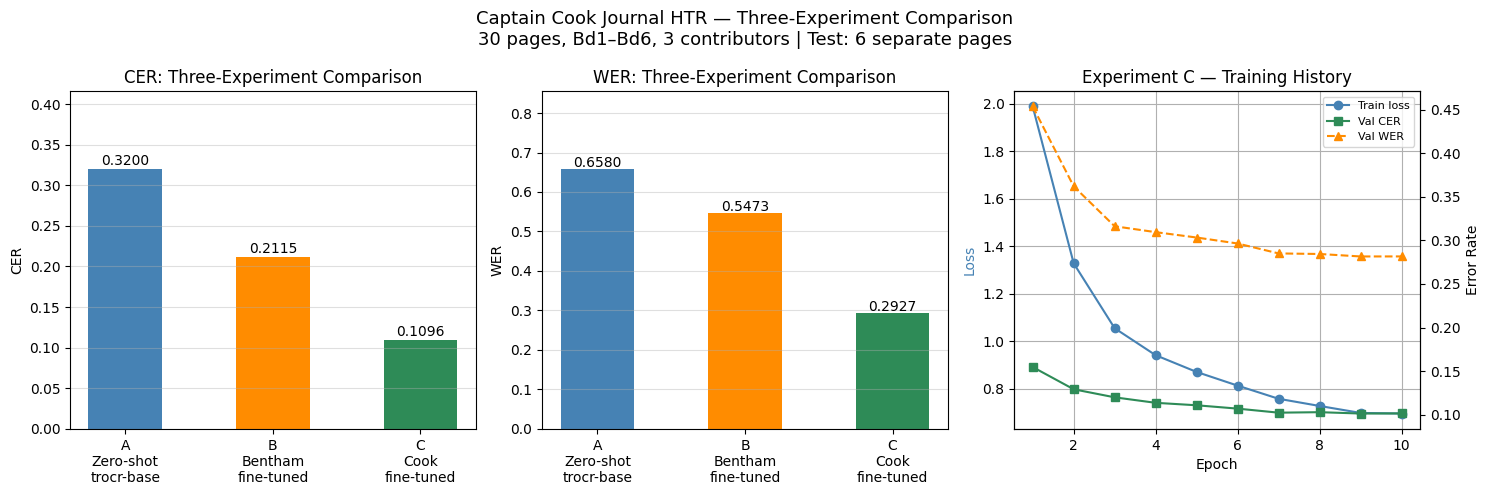

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

experiments = [
    "A\nZero-shot\ntrocr-base",
    "B\nBentham\nfine-tuned",
    "C\nCook\nfine-tuned"
]
cer_vals = [exp_a_cer, exp_b_cer, exp_c_cer]
wer_vals = [exp_a_wer, exp_b_wer, exp_c_wer]
colors   = ["steelblue", "darkorange", "seagreen"]

for ax, vals, label in [
    (axes[0], cer_vals, "CER"),
    (axes[1], wer_vals, "WER")
]:
    bars = ax.bar(experiments, vals, color=colors, width=0.5)
    ax.set_ylabel(label)
    ax.set_title(f"{label}: Three-Experiment Comparison")
    ax.set_ylim(0, max(vals) * 1.3)
    ax.grid(axis="y", alpha=0.4)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.005, f"{v:.4f}",
            ha="center", fontsize=10
        )

# Experiment C training history
epochs = range(1, len(train_loss_history) + 1)
axes[2].plot(epochs, train_loss_history,
             marker="o", color="steelblue", label="Train loss")
ax2 = axes[2].twinx()
ax2.plot(epochs, val_cer_history,
         marker="s", color="seagreen",  label="Val CER",  linestyle="-")
ax2.plot(epochs, val_wer_history,
         marker="^", color="darkorange", label="Val WER", linestyle="--")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss", color="steelblue")
ax2.set_ylabel("Error Rate")
axes[2].set_title("Experiment C — Training History")
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
axes[2].grid(True)

plt.suptitle(
    "Captain Cook Journal HTR — Three-Experiment Comparison\n"
    "30 pages, Bd1–Bd6, 3 contributors | Test: 6 separate pages",
    fontsize=13
)
plt.tight_layout()
plt.savefig("cook_three_experiments.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 12 — Save results to CSV

In [14]:
results_df = pd.DataFrame([
    {
        "experiment"  : "A — zero-shot trocr-base",
        "model"       : "microsoft/trocr-base-handwritten",
        "train_pages" : 0,
        "train_lines" : 0,
        "val_pages"   : 0,
        "val_lines"   : 0,
        "test_pages"  : len(TEST_PAGES),
        "test_lines"  : len(test_pairs),
        "cer"         : exp_a_cer,
        "wer"         : exp_a_wer,
    },
    {
        "experiment"  : "B — Bentham fine-tuned",
        "model"       : str(BENTHAM_MODEL_PATH),
        "train_pages" : 0,
        "train_lines" : 0,
        "val_pages"   : 0,
        "val_lines"   : 0,
        "test_pages"  : len(TEST_PAGES),
        "test_lines"  : len(test_pairs),
        "cer"         : exp_b_cer,
        "wer"         : exp_b_wer,
    },
    {
        "experiment"  : "C — Cook fine-tuned",
        "model"       : str(OUTPUT_MODEL_DIR),
        "train_pages" : len(TRAIN_PAGES),
        "train_lines" : len(train_pairs),
        "val_pages"   : len(VAL_PAGES),
        "val_lines"   : len(val_pairs),
        "test_pages"  : len(TEST_PAGES),
        "test_lines"  : len(test_pairs),
        "cer"         : exp_c_cer,
        "wer"         : exp_c_wer,
    }
])

results_df.to_csv(OUTPUT_CSV, index=False)
print(f"Results saved to: {OUTPUT_CSV}")
results_df

Results saved to: /Users/hedyeh/Ginger_Gradient/Capstone-Project/data/Captain_Cook/three_experiment_results.csv


,experiment,model,train_pages,train_lines,val_pages,val_lines,test_pages,test_lines,cer,wer
0,A — zero-shot trocr-base,microsoft/trocr-base-handwritten,0,0,0,0,6,189,0.319972,0.658022
1,B — Bentham fine-tuned,best_ar,0,0,0,0,6,189,0.211509,0.547266
2,C — Cook fine-tuned,cc_finetuned_model,24,764,6,202,6,189,0.109608,0.292724
